In [3]:
import h5py
import yaml
import numpy as np

with h5py.File("pixsplit_data/train/nparticles_resampled.h5", "r") as f:
    for key in f.keys():
        print(f"{key}: {f[key].shape}")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'pixsplit_data/train/nparticles_resampled.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [3]:
import h5py
import numpy as np
import yaml
import tensorflow as tf

# Using yaml 'mean' and 'std' values for normalization
# Z-Score Normalization / Standardization
with open("pixsplit_data/train/nparticles_resampled.yaml", "r") as f:
    meta = yaml.safe_load(f)

def load_split(folder_path):
    h5_path = f"{folder_path}/nparticles_resampled.h5"
    
    with h5py.File(h5_path, "r") as hf:
        # --- Y (Labels) ---
        y_int = (hf['nparticles'][:] - 1).astype(np.int32).flatten()
        y = tf.keras.utils.to_categorical(y_int, num_classes=3)

        # --- X1 (Charge Matrix) ---
        c_mean = np.array(meta['charge']['mean'], dtype=np.float32)
        c_std  = np.array(meta['charge']['std'], dtype=np.float32)
        X1 = (hf['charge'][:] - c_mean) / c_std

        # --- X2 (Context Vector) ---
        # Pitches
        p_mean = np.array(meta['pitches']['mean'], dtype=np.float32)
        p_std  = np.array(meta['pitches']['std'], dtype=np.float32)
        norm_pitches = (hf['pitches'][:] - p_mean) / p_std
        
        # Angles
        phi_mean = np.array(meta['mean_phi']['mean'], dtype=np.float32)
        phi_std  = np.array(meta['mean_phi']['std'], dtype=np.float32)
        norm_phi = (hf['mean_phi'][:] - phi_mean) / phi_std

        theta_mean = np.array(meta['mean_theta']['mean'], dtype=np.float32)
        theta_std  = np.array(meta['mean_theta']['std'], dtype=np.float32)
        norm_theta = (hf['mean_theta'][:] - theta_mean) / theta_std

        # Categorical Flags
        raw_layer = hf['layer'][:].astype(np.float32)
        raw_bec   = hf['barrelec'][:].astype(np.float32)

        # Stack into (N, 11) context vector
        X2 = np.hstack([norm_pitches, norm_phi, norm_theta, raw_layer, raw_bec])
        X = np.hstack([X1, X2])  
    return X1, X2, y

X_train_charge, X_train_context, y_train = load_split("pixsplit_data/train")
X_val_charge, X_val_context, y_val     = load_split("pixsplit_data/val")
X_test_charge, X_test_context, y_test   = load_split("pixsplit_data/test")

print(f"Loaded {len(y_train)} training samples.")
print(f"Loaded {len(y_val)} validation samples.")

Loaded 3304287 training samples.
Loaded 413034 validation samples.


In [ ]:
import numpy as np
import os

# Create a directory for the processed data
os.makedirs("processed_data", exist_ok=True)

# Save Training Set
np.save("processed_data/X_train_charge.npy", X_train_charge)
np.save("processed_data/X_train_context.npy", X_train_context)
np.save("processed_data/y_train.npy", y_train)

# Save Validation Set
np.save("processed_data/X_val_charge.npy", X_val_charge)
np.save("processed_data/X_val_context.npy", X_val_context)
np.save("processed_data/y_val.npy", y_val)

# Save Test Set
np.save("processed_data/X_test_charge.npy", X_test_charge)
np.save("processed_data/X_test_context.npy", X_test_context)
np.save("processed_data/y_test.npy", y_test)

print("All files saved to /processed_data/")

All files saved to /processed_data/


In [27]:
import numpy as np
from hgq.utils.sugar import Dataset

X_train_charge = np.load("processed_data/X_train_charge.npy")
X_train_context = np.load("processed_data/X_train_context.npy")
y_train = np.load("processed_data/y_train.npy")
X_val_charge = np.load("processed_data/X_val_charge.npy")
X_val_context = np.load("processed_data/X_val_context.npy")
y_val = np.load("processed_data/y_val.npy")
X_test_charge = np.load("processed_data/X_test_charge.npy")
X_test_context = np.load("processed_data/X_test_context.npy")
y_test = np.load("processed_data/y_test.npy")


#dataset_train = Dataset([X_train_charge, X_train_context], y_train, batch_size=33200, device='gpu:0')
#dataset_val = Dataset([X_val_charge, X_val_context], y_val, batch_size=33200, device='gpu:0')
#dataset_test = Dataset([X_test_charge, X_test_context], y_test, batch_size=33200, device='gpu:0')

In [ ]:
def augment_data(X_charge, X_context, y):
    # Reshape to 7x7 for manipulation
    X_imgs = X_charge.reshape(-1, 7, 7)
    
    # Flip horizontally
    X_flip = np.flip(X_imgs, axis=2).reshape(-1, 49)
    
    # Combine original + flipped (Doubles your dataset)
    X_charge_new = np.vstack([X_charge, X_flip])
    X_context_new = np.vstack([X_context, X_context])
    y_new = np.vstack([y, y])
    
    return X_charge_new, X_context_new, y_new

NameError: name 'X_train' is not defined

In [54]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_split_model():
    # --- BRANCH 1: CNN (Charge Grid) ---
    charge_in = layers.Input(shape=(49,), name="charge_input")
    x1 = layers.Reshape((7, 7, 1))(charge_in)

    # Block 1
    x1 = layers.Conv2D(64, (3, 3), padding='same')(x1)
    x1 = layers.LeakyReLU(alpha=0.1)(x1)

    # Block 2: Dilated Residual Block
    skip = layers.Conv2D(128, (1, 1), padding='same')(x1)

    x1 = layers.Conv2D(128, (3, 3), padding='same', dilation_rate=2)(x1)
    x1 = layers.LeakyReLU(alpha=0.1)(x1)
    x1 = layers.Conv2D(128, (3, 3), padding='same')(x1)

    x1 = layers.Add()([x1, skip])
    x1 = layers.LeakyReLU(alpha=0.1)(x1)

    # --- MULTI-REPRESENTATION FEATURE EXTRACTION ---

    # Global features
    gap = layers.GlobalAveragePooling2D()(x1)
    gmp = layers.GlobalMaxPooling2D()(x1)

    #  NEW: retain spatial relationships
    flat = layers.Flatten()(x1)
    flat = layers.Dense(64)(flat)
    flat = layers.LeakyReLU(alpha=0.1)(flat)

    x1 = layers.Concatenate()([gap, gmp, flat])

    x1 = layers.Dense(128)(x1)
    x1 = layers.LeakyReLU(alpha=0.1)(x1)

    # --- BRANCH 2: CONTEXT ---
    context_in = layers.Input(shape=(11,), name="context_input")

    x2 = layers.Dense(64)(context_in)   # 🔼 increased capacity
    x2 = layers.LeakyReLU(alpha=0.1)(x2)
    x2 = layers.Dense(32)(x2)
    x2 = layers.LeakyReLU(alpha=0.1)(x2)

    # --- FUSION ---
    merged = layers.Concatenate()([x1, x2])

    z = layers.Dense(128)(merged)
    z = layers.LeakyReLU(alpha=0.1)(z)

    z = layers.Dense(64)(z)
    z = layers.LeakyReLU(alpha=0.1)(z)

    #  less aggressive bottleneck
    z = layers.Dense(32, activation='relu', name="encoder_layer")(z)

    # Output
    output = layers.Dense(3, activation='softmax', name="output")(z)

    return models.Model(inputs=[charge_in, context_in], outputs=output)

# --- Compilation with XLA and Internal Performance Hooks ---
model = build_split_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='CategoricalCrossentropy',
    metrics=['accuracy'],
    jit_compile=True,         # Native XLA optimization
    steps_per_execution=256    # Reduces CPU-GPU overhead internally
)

model.summary()

Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ charge_input        │ (None, 49)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_15          │ (None, 7, 7, 1)   │          0 │ charge_input[0][… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 7, 7, 64)  │        640 │ reshape_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_76      │ (None, 7, 7, 64)  │          0 │ conv2d_43[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_45 (Conv2D)  │ (None, 7, 7, 128) │     73,856 │ leaky_re_lu_76[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_77      │ (None, 7, 7, 128) │          0 │ conv2d_45[0][0]   │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_46 (Conv2D)  │ (None, 7, 7, 128) │    147,584 │ leaky_re_lu_77[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_44 (Conv2D)  │ (None, 7, 7, 128) │      8,320 │ leaky_re_lu_76[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 7, 7, 128) │          0 │ conv2d_46[0][0],  │
│                     │                   │            │ conv2d_44[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_78      │ (None, 7, 7, 128) │          0 │ add_9[0][0]       │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_11          │ (None, 6272)      │          0 │ leaky_re_lu_78[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_66 (Dense)    │ (None, 64)        │    401,472 │ flatten_11[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ context_input       │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ leaky_re_lu_78[0… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ leaky_re_lu_78[0… │
│ (GlobalMaxPooling2… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ leaky_re_lu_79      │ (None, 64)        │          0 │ dense_66[0][0]    │
│ (LeakyReLU)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 64)        │        768 │ context_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_19      │ (None, 320)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ global_max_pooli… │
│                     │                   │            │ leaky_re_lu_79[0… │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 706,851 (2.70 MB)

 Trainable params: 706,851 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
from keras.callbacks import LearningRateScheduler
from hgq.utils.sugar import PBar
import math

def aggressive_early_decay(initial_lr=5e-3, first_decay_step=100, t_mul=2.0, m_mul=0.5):
    def schedule(epoch):
        n_cycle = 1
        cycle_step = epoch
        cycle_len = first_decay_step
        
        # Calculate which restart cycle we are in
        while cycle_step >= cycle_len:
            cycle_step -= cycle_len
            cycle_len *= t_mul
            n_cycle += 1

        # Cosine decay math
        cycle_t = min(cycle_step / cycle_len, 1.0)
        lr = 0.5 * initial_lr * (1 + math.cos(math.pi * cycle_t)) * (m_mul ** (n_cycle - 1))
        
        # Floor it at 1e-6 so learning doesn't totally stall
        return max(lr, 1e-6)
    
    return schedule

lr_callback = LearningRateScheduler(
    aggressive_early_decay(initial_lr=5e-3, first_decay_step=100, t_mul=2.0, m_mul=0.5)
)

In [56]:
lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2, 
    patience=1,
    min_lr=1e-6,
    verbose=1
)

# Early Stopping: Give it some room to breathe after LR cuts
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True
)

In [57]:
history = model.fit(
    x=[X_train_charge, X_train_context],
    y=y_train,
    validation_data=([X_val_charge, X_val_context], y_val),
    epochs=10,
    batch_size=1024,
    class_weight={0: 1.0, 1: 1.5, 2: 1.5},
    verbose=1,
    callbacks=[lr_callback, es_callback]
)

Epoch 1/10


2026-04-08 14:38:33.637353: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1126', 8 bytes spill stores, 8 bytes spill loads

2026-04-08 14:38:33.827268: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1077', 28 bytes spill stores, 28 bytes spill loads

2026-04-08 14:38:33.989018: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1077', 464 bytes spill stores, 468 bytes spill loads



3072/3227 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.7456 - loss: 0.7987

2026-04-08 14:39:28.719012: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1077', 104 bytes spill stores, 104 bytes spill loads

2026-04-08 14:39:28.723733: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1126_0', 392 bytes spill stores, 360 bytes spill loads

2026-04-08 14:39:28.868378: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1126', 392 bytes spill stores, 392 bytes spill loads

2026-04-08 14:39:29.183675: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1077', 564 bytes spill stores, 568 bytes spill loads



3328/3227 ━━━━━━━━━━━━━━━━━━━━ -1s 19ms/step - accuracy: 0.7469 - loss: 0.7951

2026-04-08 14:39:30.997385: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:397] ptxas warning : Registers are spilled to local memory in function 'input_multiply_reduce_fusion', 152 bytes spill stores, 152 bytes spill loads



3227/3227 ━━━━━━━━━━━━━━━━━━━━ 69s 21ms/step - accuracy: 0.7624 - loss: 0.7519 - val_accuracy: 0.7777 - val_loss: 0.5113 - learning_rate: 0.0010
Epoch 2/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 53s 16ms/step - accuracy: 0.7812 - loss: 0.7007 - val_accuracy: 0.7812 - val_loss: 0.4988 - learning_rate: 0.0010
Epoch 3/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.7865 - loss: 0.6866 - val_accuracy: 0.7826 - val_loss: 0.4978 - learning_rate: 0.0010
Epoch 4/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.7900 - loss: 0.6773 - val_accuracy: 0.7830 - val_loss: 0.4949 - learning_rate: 0.0010
Epoch 5/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 54s 17ms/step - accuracy: 0.7931 - loss: 0.6690 - val_accuracy: 0.7861 - val_loss: 0.4903 - learning_rate: 0.0010
Epoch 6/10
3227/3227 ━━━━━━━━━━━━━━━━━━━━ 53s 17ms/step - accuracy: 0.7955 - loss: 0.6621 - val_accuracy: 0.7872 - val_loss: 0.4896 - learning_rate: 0.0010
Epoch 7/10
3328/3227 ━━━━━━━━━━━━━━━━━━━━ -1s 15ms/step - accuracy: 0.7979 

In [ ]:
# In original project: Epochs = 128, batch_size = 1000
#model.fit(X_train, y_train, validation_data=(X_val, y_val), callbacks=[lr_callback], epochs=100, batch_size=1024)

NameError: name 'X_train' is not defined

In [58]:
score = model.evaluate([X_test_charge, X_test_context], y_test)
print("Test loss:", score[0])
print("Test accuracy:", score[1])

12908/12908 ━━━━━━━━━━━━━━━━━━━━ 39s 3ms/step - accuracy: 0.7880 - loss: 0.4958
Test loss: 0.49581241607666016
Test accuracy: 0.7879714369773865


In [59]:
y_pix = model.predict([X_test_charge, X_test_context])

12800/12908 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

2026-04-08 14:49:38.789049: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


12908/12908 ━━━━━━━━━━━━━━━━━━━━ 15s 1ms/step


<Figure size 800x600 with 0 Axes>

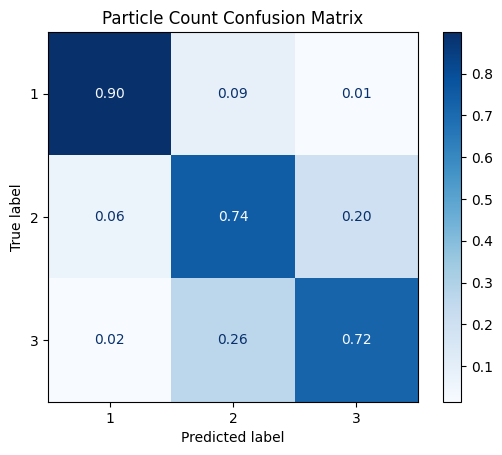

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = np.argmax(y_pix, axis=1)
y_true = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true, y_pred, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3])

plt.figure(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, values_format='.2f') # .2f shows 2 decimal places for percentages
plt.title('Particle Count Confusion Matrix')
plt.show()